# Semi-Supervised Learning with GCNs

*August 4 2026*  
*Training Workshop: Introduction to Deep Graph Learning*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

We now consider semi-supervised node classification with GCNs, i.e. we apply GCNs to a data set that contains a large number of unlabeled nodes as well as a very small set of labeled nodes. 

In [1]:
import seaborn as sns
import torch
import torch_geometric
from matplotlib import pyplot as plt

import pathpyG as pp

plt.style.use('default')
sns.set_style("whitegrid")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Running on', device)

Running on cuda


In [2]:
class GraphConvolution(torch_geometric.nn.MessagePassing):
    """A graph convolution layer following (Kipf, Welling 2017)."""

    def __init__(self, in_ch, out_ch):
        """Initialize the layer parameters."""
        super().__init__(aggr='add')

        # this linear function is used to transform node features 
        # into messages that are then "sent" to neighbors
        self.linear = torch.nn.Linear(in_ch, out_ch)
        
    def forward(self, x, edge_index):
        """Perform a graph convolution.

        This function uses the edges captured in edge_index, performs
        the graph convolution function according to (Kipf, Welling 2017)
        and propagates the transformed features along the edges of the graph.
        """
        # by adding self-loops, we ensure that aggregated messages from neighbors 
        # are combined with information from the node itself
        # this corresponds to matrix $\tilde{A}$ in (Kipf, Welling 2017)
        edge_index, _ = torch_geometric.utils.add_self_loops(edge_index, num_nodes=x.size(0))

        # we linearly transform the features of *all* nodes stored in x
        x = self.linear(x)

        # extract source and target nodes of all edges
        source, target = edge_index
        
        # compute the (in-)degrees $d_i$ of source nodes
        deg = torch_geometric.utils.degree(target, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        # with this, the normalization to be applied in the propagation step can be expressed as
        # this corresponds to D^{-0.5} A * D^{-0.5} in (Kipf, Welling 2017)
        norm = deg_inv_sqrt[source] * deg_inv_sqrt[target]
        
        # the propagate function propagates messages along the edges of the graph
        # this function internally calls the functions: message(), aggregate() and update()
        # the normalization is applied in the message() function
        return self.propagate(edge_index, x=x, norm=norm)
    
    def message(self, x_j, norm):
        """Construct the message that is sent along each edge."""
        # x_j is a so-called **lifted** tensor which contains the source node features of each edge, 
        # i.e. it has a shape (m, out_ch) where m is the number of edges

        # a call to view(-1, 1) returns a reshaped tensor, where the second dimension 
        # is one and the first dimension is inferred automatically
        return norm.view(-1,1) * x_j

class GCN(torch.nn.Module):
    """A two-layer graph convolutional network."""

    def __init__(self, data: torch_geometric.data.Data, out_ch, hidden_dim_1=16):
        """Initialize the model parameters."""
        super().__init__()

        self.input_to_hidden1 = GraphConvolution(data.num_node_features, hidden_dim_1)

        self.hidden1_to_output =  GraphConvolution(hidden_dim_1, out_ch)
        
    def forward(self, x, edge_index):
        """Compute class probabilities for all nodes."""
        # first graph convolution -> map nodes to representations in hidden_dim dimensions
        x = self.input_to_hidden1(x, edge_index)

        # non-linear activation function
        x = torch.relu(x)

        # second graph convolution -> maps node representations to output classes
        x = self.hidden1_to_output(x, edge_index)

        # output class probabilities
        return torch.sigmoid(x)        

In [ ]:
karate = pp.io.read_netzschleuder_graph(name='karate', network='78')
karate.data.node_groups = torch.tensor(karate.data.node_groups-1, dtype=torch.float)
karate.data.node_groups.unsqueeze_(-1)
karate.data.x = torch.eye(karate.n, dtype=torch.float32)
print(karate)
pp.plot(karate, edge_color='gray',  node_color=[karate["node_groups", v].item() for v in karate.nodes])

In [ ]:
labeled_nodes = [0]

model = GCN(karate.data, out_ch=1, hidden_dim_1=4)

epochs = 100
lrn_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=lrn_rate)

losses = []

model.train()
for epoch in range(epochs):

    error = 0
    for v in labeled_nodes:

        i = karate.mapping.to_idx(v)
        # set gradients to zero
        optimizer.zero_grad()

        # compute loss function for training sample and backpropagate
        output = model(karate.data.x, karate.data.edge_index)
        print(output[i], karate.data.node_groups[i])
        loss = torch.nn.functional.binary_cross_entropy(output[i], karate.data.node_groups[i])
        loss.backward()

        # update parameters
        optimizer.step()

        error += loss.detach().numpy()

    losses.append(error)

# plot evolution of loss
plt.plot(range(epochs), losses);

In [41]:
output = model.forward(karate.data.x, karate.data.edge_index)
# we efficiently map probabilities to classes by rounding values to the 
# nearest integer, i.e. we obtain class 0 for probabilities smaller than 0.5
# and class 1 for probabilities larger than 0.5
prediction = output.round().long()
colors = {}
for v in karate.nodes:
    index = karate.mapping.to_idx(v)
    if v in labeled_nodes:
        colors[v] = 'gray'
    else:
        #print(output[index])
        #print(decision(output[index]))
        if prediction[index]==0:
            colors[v] = 'CornflowerBlue'
        else:
            colors[v] = 'orange'
        
pp.plot(karate, edge_color='gray', node_color=[colors[v] for v in karate.nodes])

In [ ]:
labeled_nodes = [0, 33]
colors = {}
for v in karate.nodes:
    if v == 0:
        colors[v] = 'CornflowerBlue'
    elif v == 33:
        colors[v] = 'orange'
    else:
        colors[v] = 'gray'
pp.plot(karate, edge_color='gray', node_color=[colors[v] for v in karate.nodes])

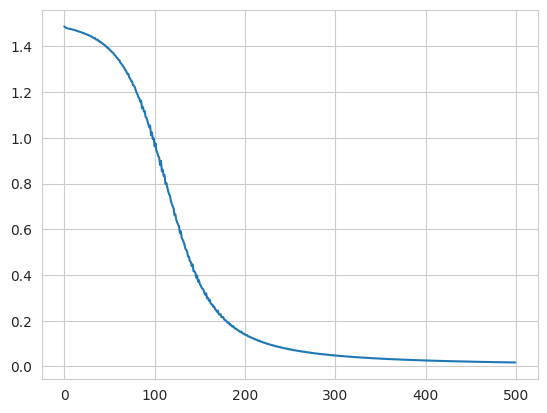

In [49]:
model = GCN(karate.data, out_ch=1, hidden_dim_1=4)

epochs = 500
lrn_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=lrn_rate)

losses = []

model.train()
for epoch in range(epochs):

    error = 0
    for v in labeled_nodes:

        i = karate.mapping.to_idx(v)

        # set gradients to zero
        optimizer.zero_grad()

        # compute loss function for training sample and backpropagate
        output = model(karate.data.x, karate.data.edge_index)
        loss = torch.nn.functional.binary_cross_entropy(output[i], karate.data.node_groups[i])
        loss.backward()

        # update parameters
        optimizer.step()

        error += loss.detach().numpy()

    losses.append(error)

# plot evolution of loss
plt.plot(range(epochs), losses);

In [50]:
output = model.forward(karate.data.x, karate.data.edge_index)
# we efficiently map probabilities to classes by rounding values to the 
# nearest integer, i.e. we obtain class 0 for probabilities smaller than 0.5
# and class 1 for probabilities larger than 0.5
prediction = output.round().long()

for v in karate.nodes:
    index = karate.mapping.to_idx(v)
    if v in labeled_nodes:
        colors[v] = 'gray'
    else:
        #print(output[index])
        #print(decision(output[index]))
        if prediction[index]==0:
            colors[v] = 'CornflowerBlue'
        else:
            colors[v] = 'orange'
        
pp.plot(karate, edge_color='gray', node_color=[colors[v] for v in karate.nodes])